In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("..\data\investments_VC_new.csv")

## Q.1  How balanced is the dataset between acquired and closed startups?

In [3]:
df["status"].value_counts()
# Percentages
df["status"].value_counts(normalize=True) * 100

status
acquired    58.677686
closed      41.322314
Name: proportion, dtype: float64

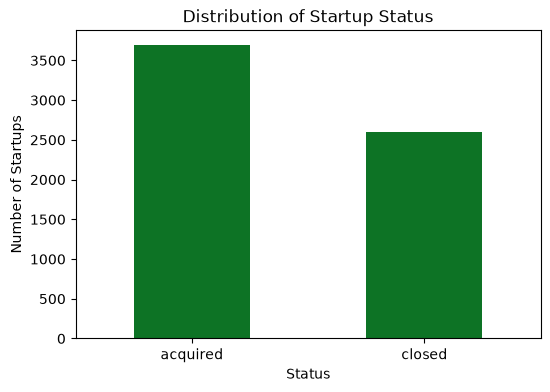

In [4]:
status_counts = df["status"].value_counts()

plt.figure(figsize=(6, 4))
status_counts.plot(kind="bar",color="#0d7325")

plt.title("Distribution of Startup Status")
plt.xlabel("Status")
plt.ylabel("Number of Startups")

plt.xticks(rotation=0)

plt.show()

## Q.2 Do acquired startups raise more capital than closed startups?

In [5]:
print(df["funding_total_usd"].describe())

print("Skewness:", df["funding_total_usd"].skew())

count    5.374000e+03
mean     1.766109e+07
std      9.351468e+07
min      1.000000e+03
25%      8.427620e+05
50%      4.500000e+06
75%      1.550000e+07
max      5.700000e+09
Name: funding_total_usd, dtype: float64
Skewness: 44.43854580638899


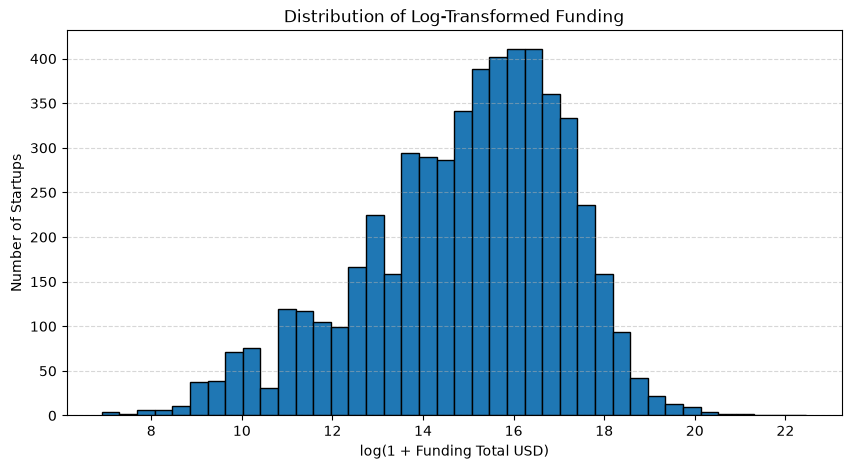

In [6]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(df["funding_total_usd"].dropna()),
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Log-Transformed Funding")
plt.xlabel("log(1 + Funding Total USD)")
plt.ylabel("Number of Startups")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Real Dataset is right-skewed because mean >> median. but when we do log-transformation, data looks like a left-skewed. 

In [7]:
log_funding = np.log1p(df["funding_total_usd"])

print("Original skew:",
      df["funding_total_usd"].skew())

print("Log skew:",
      log_funding.skew())

Original skew: 44.43854580638899
Log skew: -0.6176050062314866


##### The original funding_total_usd variable exhibited extreme positive skewness (44.44), indicating that a small number of startups raised exceptionally large amounts of funding. A logarithmic transformation (log1p) reduced the skewness to -0.62, producing a much more balanced distribution that is easier to interpret during exploratory analysis.

## Q.3 Does raising more funding rounds increase the likelihood of acquisition?

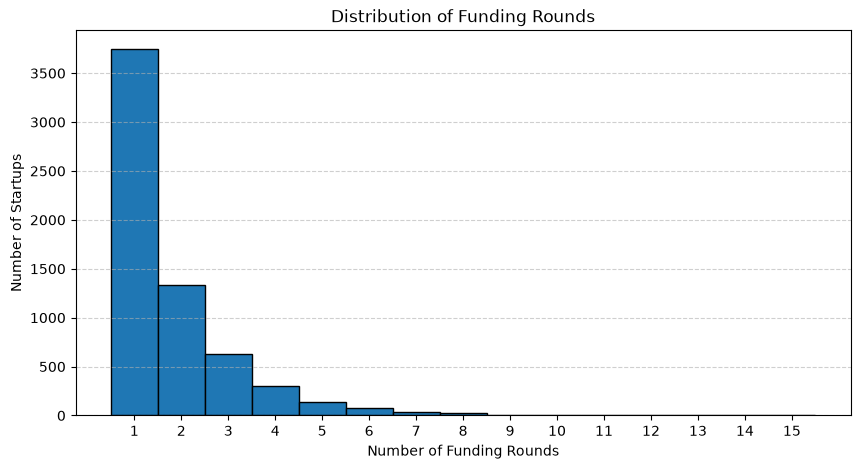

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["funding_rounds"].dropna(),
    bins=range(
        int(df["funding_rounds"].min()),
        int(df["funding_rounds"].max()) + 2
    ),
    edgecolor="black",
    align="left"
)

plt.title("Distribution of Funding Rounds")
plt.xlabel("Number of Funding Rounds")
plt.ylabel("Number of Startups")

plt.xticks(range(
    int(df["funding_rounds"].min()),
    int(df["funding_rounds"].max()) + 1
))

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [9]:
print(df["funding_rounds"].describe())
print("Skewness:", df["funding_rounds"].skew())
df["funding_rounds"].value_counts().sort_index()

count    6292.000000
mean        1.774476
std         1.270765
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        15.000000
Name: funding_rounds, dtype: float64
Skewness: 2.4292193980586414


funding_rounds
1     3749
2     1337
3      632
4      298
5      133
6       74
7       34
8       22
9        7
10       2
11       3
15       1
Name: count, dtype: int64

In [10]:
one_or_two = (
    df["funding_rounds"]
      .isin([1, 2])
      .mean() * 100
)

print(f"{one_or_two:.2f}%")

80.83%


## Q.4 Do acquired startups raise more capital than closed startups?

In [11]:
## Summary Statistics 

df.groupby("status")["funding_total_usd"].agg(
    count="count",
    median="median",
    mean="mean",
    std="std",
    min="min",
    max="max"
).round(0)

,count,median,mean,std,min,max
status,,,,,,
acquired,3218,8382400.0,23813035.0,115311805.0,1265.0,5.700000e+09
closed,2156,1000000.0,8478830.0,42581653.0,1000.0,1.567504e+09


<Figure size 800x600 with 0 Axes>

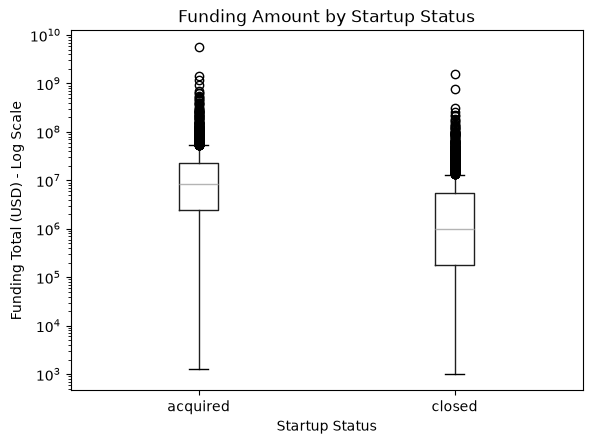

In [12]:
## BoxPlot

plt.figure(figsize=(8,6))

df.boxplot(
    column="funding_total_usd",
    by="status",
    grid=False
)

plt.yscale("log")

plt.title("Funding Amount by Startup Status")
plt.suptitle("")

plt.xlabel("Startup Status")
plt.ylabel("Funding Total (USD) - Log Scale")

plt.show()

In [13]:
## Mann-Whitney U Test (Dataset is right skewed which caused to neglect the T-Test).

from scipy.stats import mannwhitneyu

acquired = df.loc[
    df["status"] == "acquired",
    "funding_total_usd"
].dropna()

closed = df.loc[
    df["status"] == "closed",
    "funding_total_usd"
].dropna()

stat, p = mannwhitneyu(
    acquired,
    closed,
    alternative="two-sided"
)
u_stat, p_value = mannwhitneyu(
    acquired,
    closed,
    alternative="two-sided"
)

print("Statistic :", u_stat)
print("P-value   :", p_value)

Statistic : 5216853.0
P-value   : 8.456500504202281e-216


In [14]:
n1 = len(acquired)
n2 = len(closed)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print(f"Rank-Biserial Correlation: {rank_biserial:.4f}")

Rank-Biserial Correlation: 0.5038


#### Business Analysis:- he analysis indicates that acquired startups generally raise substantially more funding than startups that eventually close. The median funding amount for acquired startups ($8.38M) is more than eight times that of closed startups ($1.00M). A Mann–Whitney U test confirmed that this difference is statistically significant (p < 0.001), and the Rank-Biserial Correlation (0.504) indicates a large practical effect. These findings suggest that total funding is a strong candidate predictor of startup exit outcomes and should be retained as an important feature for predictive modeling.

## Q.5 Are startups that survive multiple rounds less likely to fail?

In [15]:
## Summary Statistics 

df.groupby("status")["funding_total_usd"].agg(
    count="count",
    median="median",
    mean="mean",
    std="std",
    min="min",
    max="max"
).round(0)

,count,median,mean,std,min,max
status,,,,,,
acquired,3218,8382400.0,23813035.0,115311805.0,1265.0,5.700000e+09
closed,2156,1000000.0,8478830.0,42581653.0,1000.0,1.567504e+09


In [16]:
df["funding_rounds_group"] = np.where(
    df["funding_rounds"] >= 6,
    "6+",
    df["funding_rounds"].astype(int).astype(str)
)
df["funding_rounds_group"].value_counts().sort_index()

funding_rounds_group
1     3749
2     1337
3      632
4      298
5      133
6+     143
Name: count, dtype: int64

In [17]:
contingency_table = pd.crosstab(
    df["funding_rounds_group"],
    df["status"]
)

contingency_table

status,acquired,closed
funding_rounds_group,,
1,1824,1925
2,898,439
3,508,124
4,235,63
5,110,23
6+,117,26


In [18]:
acquisition_rate = (
    contingency_table["acquired"] /
    contingency_table.sum(axis=1)
) * 100

acquisition_rate = acquisition_rate.reset_index(name="acquisition_rate")

acquisition_rate

,funding_rounds_group,acquisition_rate
0,1,48.652974
1,2,67.165295
2,3,80.379747
3,4,78.859060
4,5,82.706767
5,6+,81.818182


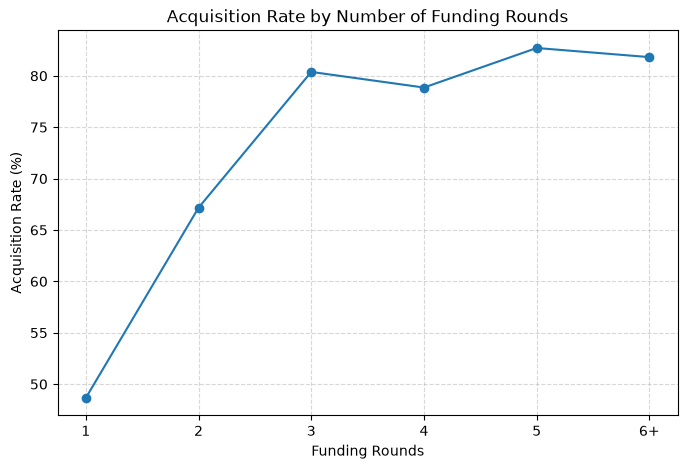

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    acquisition_rate["funding_rounds_group"],
    acquisition_rate["acquisition_rate"],
    marker="o"
)

plt.title("Acquisition Rate by Number of Funding Rounds")
plt.xlabel("Funding Rounds")
plt.ylabel("Acquisition Rate (%)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [20]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_value:}")

Chi-square Statistic : 431.1756
Degrees of Freedom   : 5
P-value              : 5.639238886696959e-91


In [21]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("Funding rounds and startup status are associated.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("No significant association between funding rounds and startup status.")

Reject the Null Hypothesis (H₀)
Funding rounds and startup status are associated.


### Startups that progress through additional funding rounds exhibit progressively higher acquisition rates. This suggests that startup funding maturity is positively associated with acquisition outcomes.

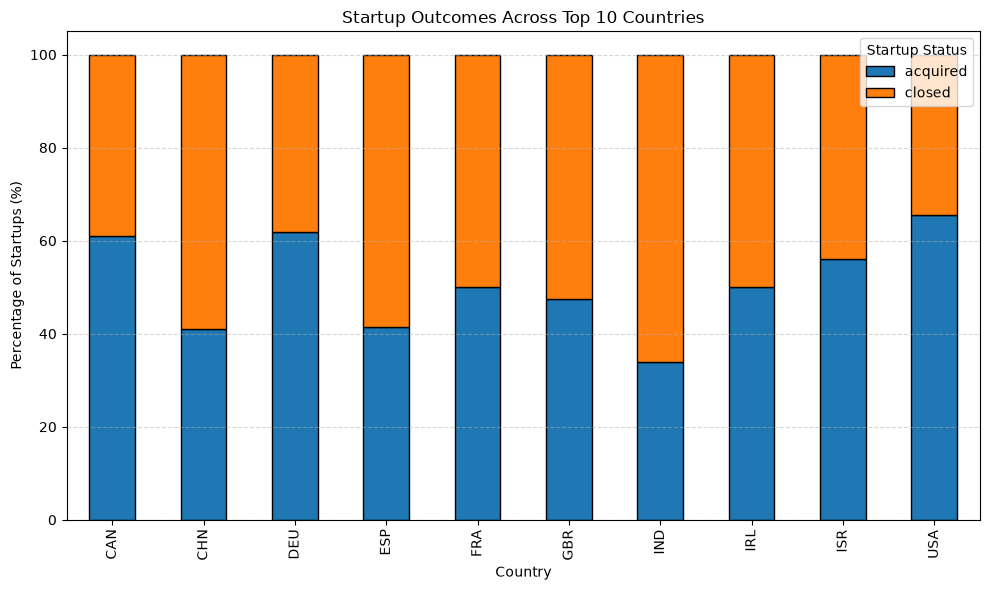

In [22]:
# Top 10 countries by number of startups
top10_countries = (
    df["country_code"]
      .value_counts()
      .head(10)
      .index
)

country_df = df[df["country_code"].isin(top10_countries)]

# Create contingency table
country_status = pd.crosstab(
    country_df["country_code"],
    country_df["status"]
)

# Convert counts to percentages
country_status_pct = (
    country_status.div(country_status.sum(axis=1), axis=0) * 100
)

# Plot
country_status_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    edgecolor="black"
)

plt.title("Startup Outcomes Across Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Percentage of Startups (%)")

plt.legend(title="Startup Status")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [23]:
heatmap_cols = [
    "funding_total_usd",
    "funding_rounds",
    "seed",
    "venture",
    "angel",
    "grant",
    "private_equity",
    "debt_financing",
    "convertible_note",
    "equity_crowdfunding",
    "round_A",
    "round_B",
    "round_C",
    "round_D",
    "round_E",
    "round_F",
    "round_G",
    "round_H"
]

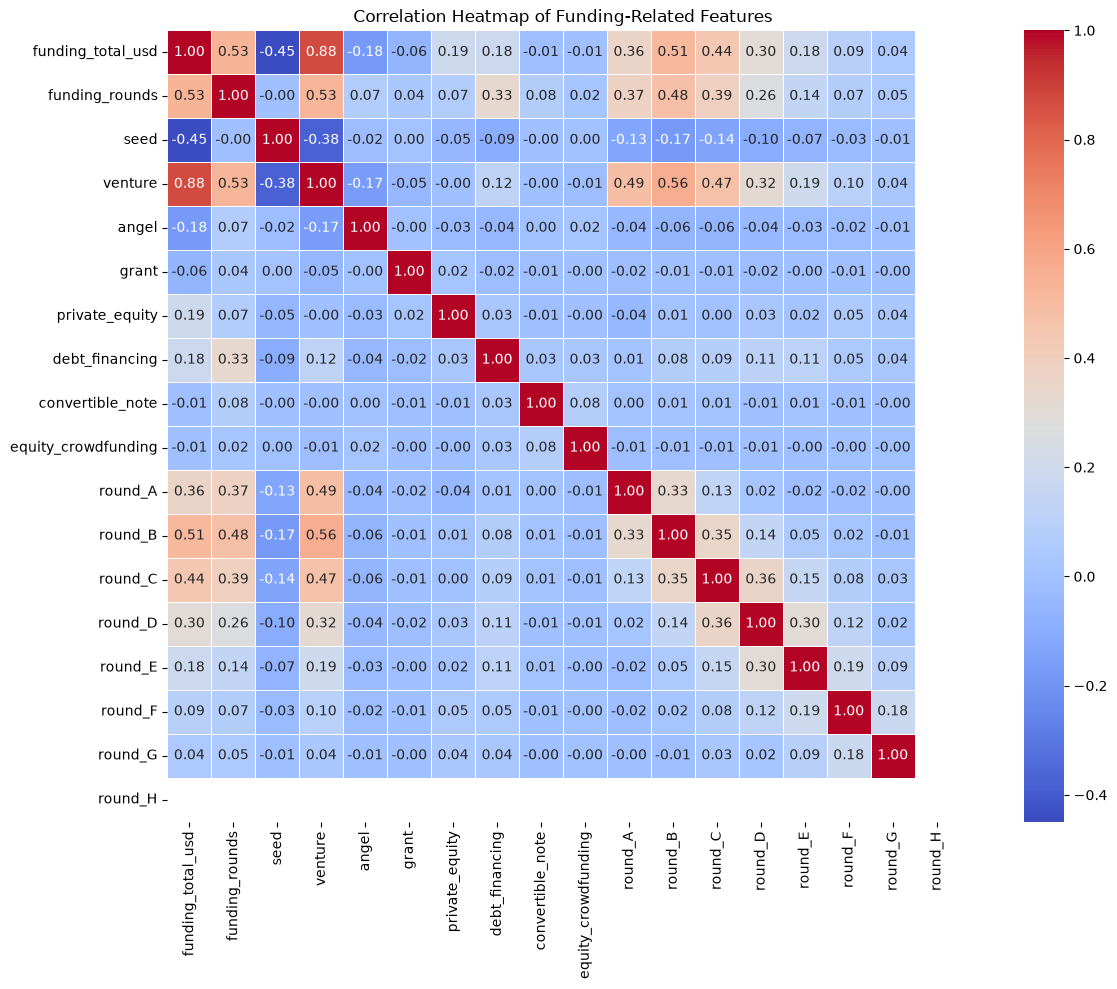

In [24]:
corr = df[heatmap_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Funding-Related Features")

plt.tight_layout()

plt.show()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6292 entries, 0 to 6291
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   category_list         6063 non-null   str    
 1   market                6061 non-null   str    
 2   funding_total_usd     5374 non-null   float64
 3   status                6292 non-null   str    
 4   country_code          5665 non-null   str    
 5   state_code            4415 non-null   str    
 6   region                5665 non-null   str    
 7   city                  5602 non-null   str    
 8   funding_rounds        6292 non-null   int64  
 9   founded_at            4527 non-null   str    
 10  founded_month         4964 non-null   str    
 11  founded_quarter       4964 non-null   str    
 12  founded_year          4964 non-null   float64
 13  first_funding_at      6292 non-null   str    
 14  last_funding_at       6292 non-null   str    
 15  seed                  6292 non-n

: 